In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import awkward as ak
import uproot

In [31]:
# file location Bs signal
filepath = '/r02/lhcb/ejnw2/fcc_2025/FCCAnalyses/examples/FCCee/flavour/B2Inv/outputs/prelim_cuts/Bs_test.root'
# Create instance of uproot, we have opened the file
uproot_file = uproot.open( filepath)

# Look at trees in file
print( "Trees : " , uproot_file.keys() )

# We want output events
tree = uproot_file['events']

'''
print( "Variables:" )

for branch in tree.keys():
    print( branch )
'''

# Get data out

# define variables we want out

branches= [
'unitEVT_sum_Rec_px',
'unitEVT_sum_Rec_py',
'unitEVT_sum_Rec_pz',
'EVT_hemisEmin_maxpChargedRP_fromPV_transformed',
'EVT_hemisEmax_maxpChargedRP_fromPV_transformed',

  #New variables for log d2PV with map for 0s to 10 (ie. events with no SV)
'ln_Rec_vtx_d2PV_min_hemisEmin',
'ln_Rec_vtx_d2PV_max_hemisEmin',
'ln_Rec_vtx_d2PV_ave_hemisEmin',
'ln_Rec_vtx_d2PV_min_hemisEmax',
'ln_Rec_vtx_d2PV_max_hemisEmax',
'ln_Rec_vtx_d2PV_ave_hemisEmax',

  ##Add log of IP-like variables, map 0 -> 10 (0s not as big a problem as with d2PV as to do with individual tracks not vertices)
'ln_Rec_track_absd0_min_hemisEmin',
'ln_Rec_track_absd0_max_hemisEmin',
'ln_Rec_track_absd0_ave_hemisEmin',

'ln_Rec_track_absd0_min_hemisEmax',
'ln_Rec_track_absd0_max_hemisEmax',
'ln_Rec_track_absd0_ave_hemisEmax',
 'ln_Rec_track_absd0chi2_max_hemisEmax',           

]

df = tree.arrays(
    expressions = branches , 
    library = 'pd' ,
)



Trees :  ['events;12', 'eventsProcessed;1', 'eventsSelected;1']


In [32]:
df

,unitEVT_sum_Rec_px,unitEVT_sum_Rec_py,unitEVT_sum_Rec_pz,EVT_hemisEmin_maxpChargedRP_fromPV_transformed,EVT_hemisEmax_maxpChargedRP_fromPV_transformed,ln_Rec_vtx_d2PV_min_hemisEmin,ln_Rec_vtx_d2PV_max_hemisEmin,ln_Rec_vtx_d2PV_ave_hemisEmin,ln_Rec_vtx_d2PV_min_hemisEmax,ln_Rec_vtx_d2PV_max_hemisEmax,ln_Rec_vtx_d2PV_ave_hemisEmax,ln_Rec_track_absd0_min_hemisEmin,ln_Rec_track_absd0_max_hemisEmin,ln_Rec_track_absd0_ave_hemisEmin,ln_Rec_track_absd0_min_hemisEmax,ln_Rec_track_absd0_max_hemisEmax,ln_Rec_track_absd0_ave_hemisEmax,ln_Rec_track_absd0chi2_max_hemisEmax
0,-0.486982,-0.648775,0.584756,1.0,0.0,10.000000,10.000000,10.000000,0.910891,1.880338,1.508762,-7.297648,-1.696359,-3.388508,-5.757757,0.945120,-1.072340,4.521660
1,-0.038570,-0.202206,0.978583,1.0,0.0,3.536148,3.536148,3.536148,0.133781,0.133781,0.133781,-4.278595,1.225238,-0.277586,-5.694298,-1.924581,-2.667845,1.617146
2,0.244888,-0.332291,-0.910831,1.0,0.0,10.000000,10.000000,10.000000,2.185051,3.137328,2.770503,-3.766653,-3.287313,-3.498533,-3.913286,1.058824,-0.298940,5.375294
3,0.372108,-0.694735,0.615532,0.0,0.0,-4.973778,-4.973778,-4.973778,-0.697715,5.714706,4.620425,-5.880469,1.854305,-0.660601,-6.537583,4.634259,1.871821,4.994338
4,-0.256313,-0.165786,-0.952270,1.0,0.0,3.383132,3.383132,3.383132,5.522329,5.522329,5.522329,-4.157079,2.181126,0.592372,-3.098871,2.482738,0.708044,4.004089
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91223,-0.586122,-0.590244,-0.555043,1.0,0.0,10.000000,10.000000,10.000000,2.135366,2.135366,2.135366,-6.276081,-2.749835,-3.810738,-5.962820,0.163789,-1.304484,5.480280
91224,0.440951,-0.395488,0.805699,1.0,1.0,10.000000,10.000000,10.000000,3.922596,3.922596,3.922596,-7.412462,-3.643910,-4.580513,-6.983329,1.926640,0.381187,4.483276
91225,-0.530686,-0.547709,0.646829,1.0,0.0,10.000000,10.000000,10.000000,-0.748330,5.128942,4.037715,-5.211515,-5.211515,-5.211515,-3.495636,2.804102,1.110182,4.577615
91226,-0.935397,0.265073,0.234029,1.0,0.0,10.000000,10.000000,10.000000,2.838916,5.045971,4.160438,-6.705930,-0.353362,-2.317938,-7.127691,2.581374,0.770794,6.385139


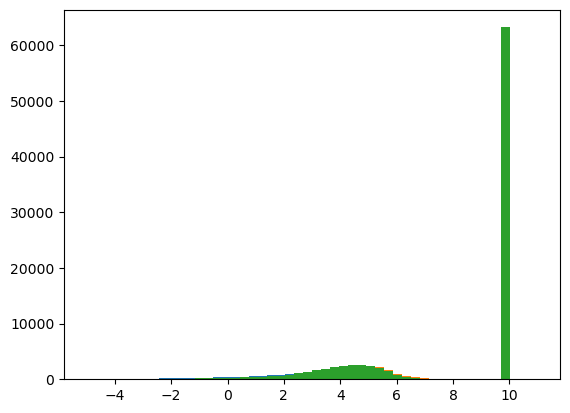

In [33]:
plt.hist(df['ln_Rec_vtx_d2PV_min_hemisEmin'],bins=50,range=(-5,11))
plt.hist(df['ln_Rec_vtx_d2PV_max_hemisEmin'],bins=50,range=(-5,11))
plt.hist(df['ln_Rec_vtx_d2PV_ave_hemisEmin'],bins=50,range=(-5,11))
plt.show()

In [34]:
columns_identical = (df['ln_Rec_vtx_d2PV_min_hemisEmin'] == df['ln_Rec_vtx_d2PV_ave_hemisEmin']).all()
columns_identical

False

In [35]:
difference = df[df['ln_Rec_vtx_d2PV_min_hemisEmin'] != df['ln_Rec_vtx_d2PV_ave_hemisEmin']]
difference

,unitEVT_sum_Rec_px,unitEVT_sum_Rec_py,unitEVT_sum_Rec_pz,EVT_hemisEmin_maxpChargedRP_fromPV_transformed,EVT_hemisEmax_maxpChargedRP_fromPV_transformed,ln_Rec_vtx_d2PV_min_hemisEmin,ln_Rec_vtx_d2PV_max_hemisEmin,ln_Rec_vtx_d2PV_ave_hemisEmin,ln_Rec_vtx_d2PV_min_hemisEmax,ln_Rec_vtx_d2PV_max_hemisEmax,ln_Rec_vtx_d2PV_ave_hemisEmax,ln_Rec_track_absd0_min_hemisEmin,ln_Rec_track_absd0_max_hemisEmin,ln_Rec_track_absd0_ave_hemisEmin,ln_Rec_track_absd0_min_hemisEmax,ln_Rec_track_absd0_max_hemisEmax,ln_Rec_track_absd0_ave_hemisEmax,ln_Rec_track_absd0chi2_max_hemisEmax
5,0.956214,-0.278376,0.090342,1.0,1.0,0.254710,5.307744,4.446418,1.246846,1.277928,1.262508,-6.444013,3.627462,1.516979,-6.005619,-0.761797,-1.946878,3.828593
72,-0.061414,-0.272720,-0.960131,0.0,0.0,3.222823,5.322959,4.745317,1.738980,4.594867,3.617771,-4.494250,1.848384,0.500016,-4.758145,1.516221,0.097642,4.483805
85,0.202135,0.761338,0.616040,0.0,1.0,0.849213,0.896504,0.873138,10.000000,10.000000,10.000000,-3.696727,0.034873,-0.824795,-6.601978,-3.168737,-4.221567,0.916129
88,-0.461076,0.627129,-0.627789,0.0,0.0,5.248654,5.926426,5.643896,-1.636208,1.810559,1.148763,-4.774606,4.574773,2.667266,-4.807011,-0.571767,-1.971480,4.282534
126,-0.406277,-0.295672,-0.864591,0.0,0.0,-3.800269,6.681455,5.605506,2.262074,2.445215,2.357831,-5.327343,5.126424,2.588900,-4.390823,1.173511,-0.368228,5.339078
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91057,0.452745,-0.717551,-0.529285,1.0,0.0,1.966166,4.213809,3.621093,0.224993,5.372389,4.285423,-7.094358,2.212705,0.776219,-7.030033,4.185362,2.092662,5.374028
91073,0.717120,-0.248811,-0.651024,1.0,-1.0,1.427396,3.730756,3.132848,-2.809706,1.670678,0.754065,-5.328657,1.222166,-0.368752,-6.292937,1.367793,-0.563691,4.033641
91097,0.398451,0.570774,0.717951,1.0,0.0,2.505602,4.527547,3.958737,0.634604,0.634604,0.634604,-7.107834,2.671917,1.275041,-4.731479,-0.027097,-1.116826,4.319694
91136,0.355203,0.165113,0.920092,0.0,0.0,4.933098,5.739043,5.415157,1.164040,4.678114,4.014307,-5.645898,3.960945,2.158250,-5.636013,0.904368,-0.815209,3.617769


(array([ 2023., 12289., 76916.]),
 array([-1.        , -0.33333334,  0.33333334,  1.        ]),
 <BarContainer object of 3 artists>)

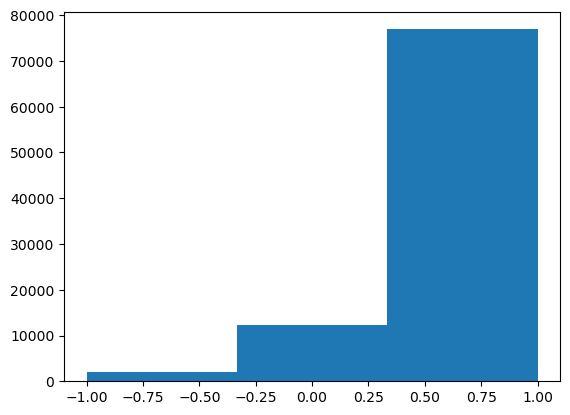

In [36]:
plt.hist(df['EVT_hemisEmin_maxpChargedRP_fromPV_transformed'],bins=3)

(array([19405., 61421., 10402.]),
 array([-1.        , -0.33333334,  0.33333334,  1.        ]),
 <BarContainer object of 3 artists>)

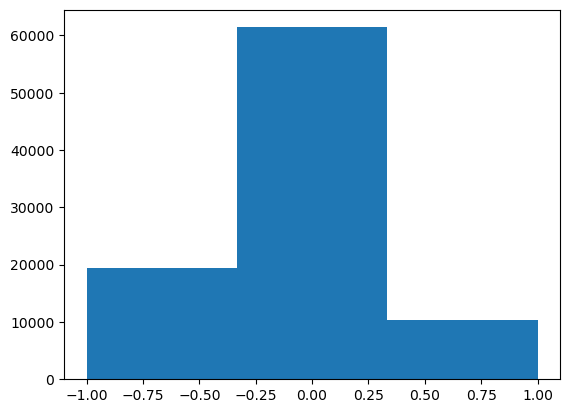

In [37]:
plt.hist(df['EVT_hemisEmax_maxpChargedRP_fromPV_transformed'],bins=3)

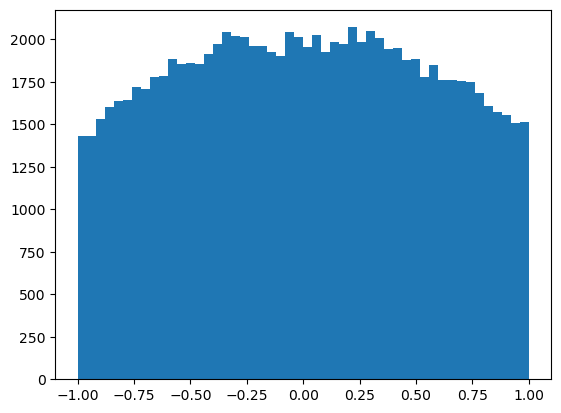

In [38]:
plt.hist(df['unitEVT_sum_Rec_px'],bins=50)
plt.show()

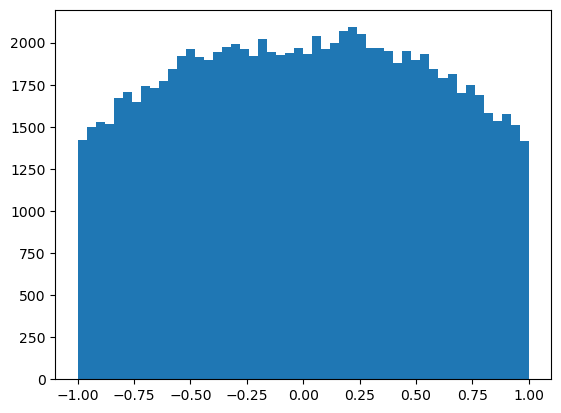

In [39]:
plt.hist(df['unitEVT_sum_Rec_py'],bins=50)
plt.show()

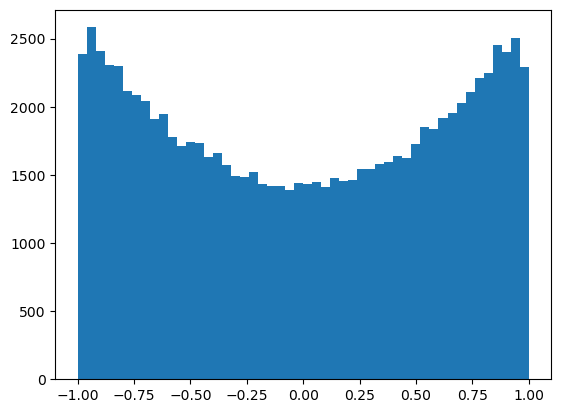

In [40]:
plt.hist(df['unitEVT_sum_Rec_pz'],bins=50)
plt.show()

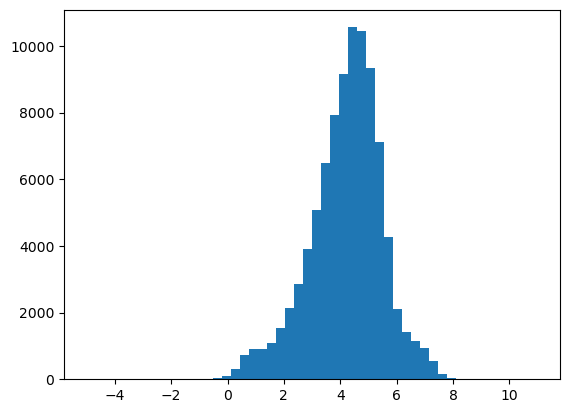

In [41]:
plt.hist(df['ln_Rec_track_absd0chi2_max_hemisEmax'],bins=50,range=(-5,11))
plt.show()